In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

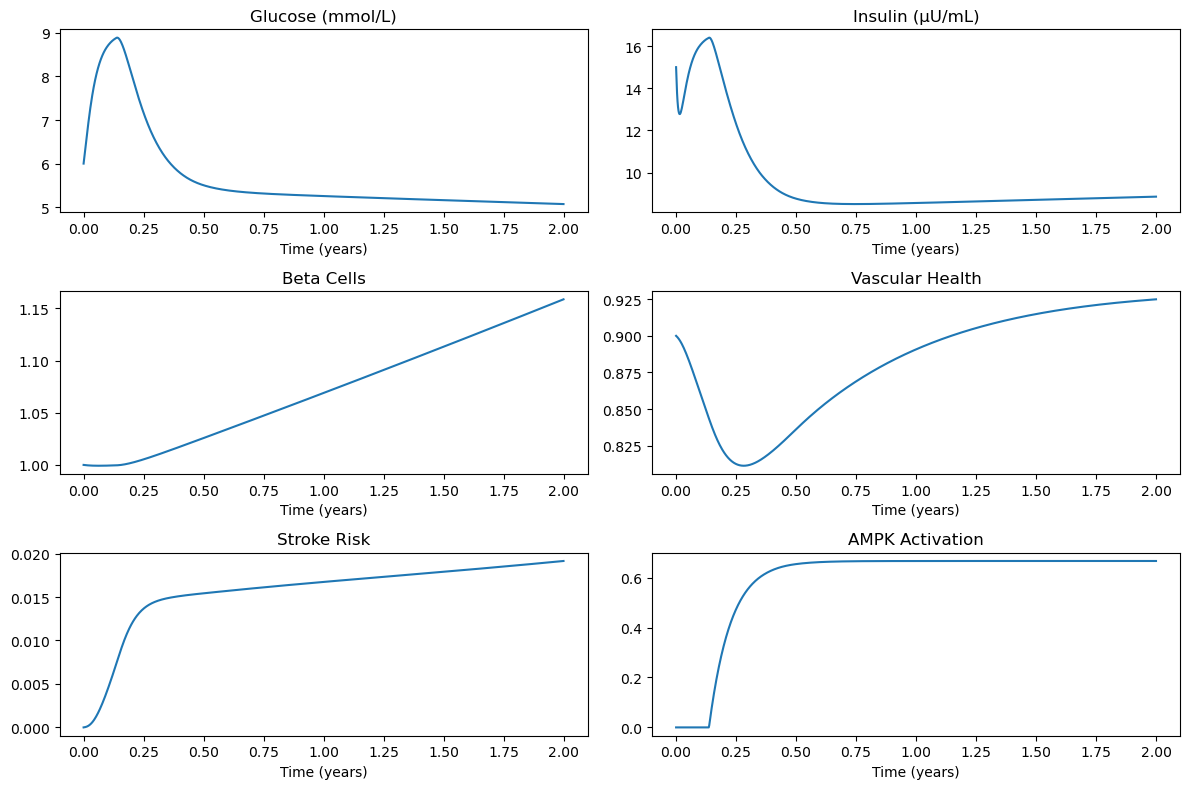

In [2]:


############################################################
# PARAMETERS (stabilised & physiologically reasonable)
############################################################

params = {
    # Glucose
    "Ra": 0.5,
    "Rhep": 0.7,
   # "Ra": 0.8,
  #  "Rhep": 1.0,
    "Uii": 0.9,

    "k1": 0.004,   # ↑ stronger glucose clearance
    "RI": 2.0,     # ↓ less resistance
    
   # "k1": 0.002,
   # "RI": 2.5,

    # Insulin
    "k2": 0.3, #0.2,
    "sigma": 8, #15.0,
    "G0": 7.0,
    "n": 2.0,

    # Beta cells (slow)
   # "rB": 0.0005,
  #  "dB": 0.0003,

    "rB": 0.0002,
    "dB": 0.0001,
    "chiA": 0.0005,

    # Chronic insulin
    "epsilon": 0.005,

    # Vascular (bounded formulation)

    
    #"alpha": 0.002,
    #"gamma": 0.0002,
    #"delta": 0.01,
    "zetaA": 0.3,

    "alpha": 0.0005,
    "gamma": 0.00005,
    "delta": 0.005,
  
    
    # Stroke
   # "kappa": 0.0005,
   # "theta": 0.0002,

    "kappa": 0.00005,
    "theta": 0.00002,

    # AMPK
    "kon": 0.02,
    "koff": 0.01,

    # Modifiers
    "etaA": 0.4,
    "xiA": 0.4,
    #"etaA": 0.3,
    #"xiA": 0.3,
    "rhoA": 0.3,

    "Gnorm": 5.5
}

############################################################
# METFORMIN DOSING
############################################################

def D(t):
    return 1.0 if t > 50 else 0.0  # treatment starts at t=50


############################################################
# MODEL
############################################################

def model(t, y, p):
    G, I, B, V, S, A, Ic = y

    # --- Enforce positivity (numerical safeguard) ---
    G = max(G, 0)
    I = max(I, 0)
    B = max(B, 1e-6)
    Ic = max(Ic, 0)
    V = min(max(V, 0), 1)
    S = min(max(S, 0), 1)
    A = min(max(A, 0), 1)

    # unpack
    Ra = p["Ra"]
    Rhep = p["Rhep"]
    Uii = p["Uii"]
    k1 = p["k1"]
    RI = p["RI"]

    k2 = p["k2"]
    sigma = p["sigma"]
    G0 = p["G0"]
    n = p["n"]

    rB = p["rB"]
    dB = p["dB"]
    chiA = p["chiA"]

    epsilon = p["epsilon"]

    alpha = p["alpha"]
    gamma = p["gamma"]
    delta = p["delta"]
    zetaA = p["zetaA"]

    kappa = p["kappa"]
    theta = p["theta"]

    kon = p["kon"]
    koff = p["koff"]

    etaA = p["etaA"]
    xiA = p["xiA"]
    rhoA = p["rhoA"]

    Gnorm = p["Gnorm"]

    ########################################################
    # EQUATIONS
    ########################################################

    # --- Glucose ---
    dGdt = (
        Ra
        + Rhep * (1 - xiA * A)
        - Uii
        - k1 * (1 + etaA * A) * (I / RI) * G
    )

    # --- Insulin ---
    secretion = B * sigma * (1 / (1 + rhoA * A)) * (G**n / (G**n + G0**n))
    dIdt = -k2 * I + secretion

    # --- Beta cells ---
    dBdt = B * rB * (G / Gnorm - 1) - dB * B + chiA * A * B

    # --- Chronic insulin ---
    dIcdt = epsilon * (I - Ic)

    # --- Vascular health (CORRECTED BOUNDED FORM) ---
    glucose_excess = max(G - Gnorm, 0)
    damage = alpha * glucose_excess + gamma * Ic
    repair = delta * (1 - V) * (1 + zetaA * A)

    dVdt = repair - damage * V

    # --- Stroke risk ---
    hazard = kappa * (1 - V) + theta * (G - Gnorm)**2
    dSdt = hazard * (1 - S)

    # --- AMPK ---
    dAdt = kon * D(t) * (1 - A) - koff * A

    return [dGdt, dIdt, dBdt, dVdt, dSdt, dAdt, dIcdt]


############################################################
# INITIAL CONDITIONS
############################################################

y0 = [
    6.0,    # G
    15.0,   # I
    1.0,    # B
    0.9,    # V
    0.0,    # S
    0.0,    # A
    15.0    # Ic
]

############################################################
# SOLVE (STIFF SOLVER)
############################################################

t_span = (0, 2*365)
t_eval = np.linspace(*t_span, 1000)

sol = solve_ivp(
    model,
    t_span,
    y0,
    args=(params,),
    t_eval=t_eval,
    method="LSODA"
)

# After solving
years = sol.t / 365

# Then use this instead of sol.t

############################################################
# PLOT
############################################################

G, I, B, V, S, A, Ic = sol.y

plt.figure(figsize=(12,8))

plt.subplot(3,2,1)
plt.plot(years, G)
plt.xlabel("Time (years)")
plt.title("Glucose (mmol/L)")

plt.subplot(3,2,2)
plt.plot(years, I)
plt.xlabel("Time (years)")
plt.title("Insulin (µU/mL)")

plt.subplot(3,2,3)
plt.plot(years, B)
plt.xlabel("Time (years)")
plt.title("Beta Cells")

plt.subplot(3,2,4)
plt.plot(years, V)
plt.xlabel("Time (years)")
plt.title("Vascular Health")

plt.subplot(3,2,5)
plt.plot(years, S)
plt.xlabel("Time (years)")
plt.title("Stroke Risk")

plt.subplot(3,2,6)
plt.plot(years, A)
plt.xlabel("Time (years)")
plt.title("AMPK Activation")

plt.tight_layout()

import os
os.makedirs("figures", exist_ok=True)

plt.savefig("figures/model_output.png", dpi=300, bbox_inches="tight")
plt.show()

In [3]:
print("Max Insulin:", max(I))
print("Final Glucose:", G[-1])
print("Final Vascular:", V[-1])
print("Final Stroke Risk:", S[-1])

Max Insulin: 16.399329170662902
Final Glucose: 5.070938720825924
Final Vascular: 0.9249292170958324
Final Stroke Risk: 0.01914521481205862


PermissionError: [Errno 13] Permission denied: 'figures/AMPK.pdf'

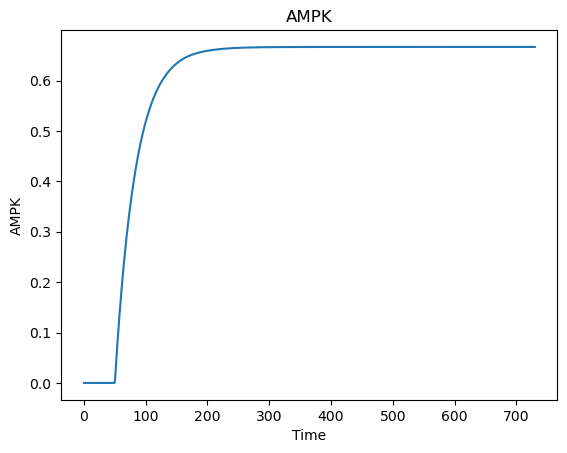

In [4]:
variables = {
    "Glucose": G,
    "Insulin": I,
    "BetaCells": B,
    "Vascular": V,
    "StrokeRisk": S,
    "AMPK": A
}

for name, data in variables.items():
    plt.figure()
    plt.plot(sol.t, data)
    plt.title(name)
    plt.xlabel("Time")
    plt.ylabel(name)
    plt.savefig(f"figures/{name}.pdf", bbox_inches="tight")
    plt.close()

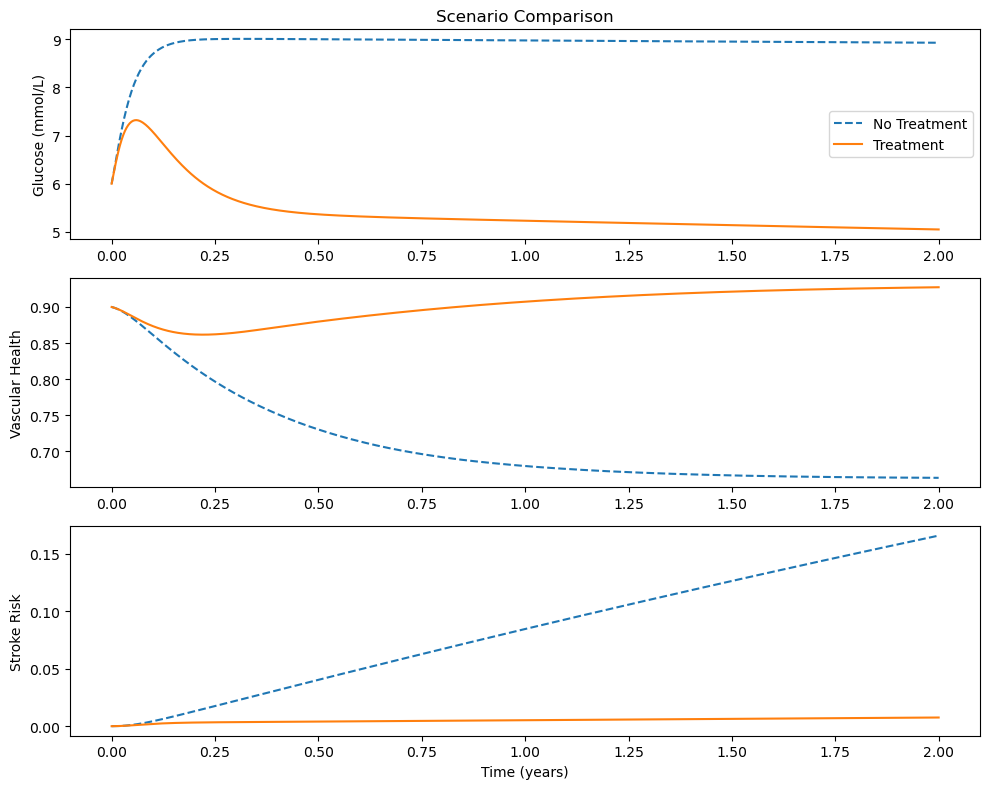

In [6]:
############################################################
# SCENARIO DEFINITIONS
############################################################

def D_no_treatment(t):
    return 0.0

def D_treatment(t):
    return 1.0


############################################################
# RUN SIMULATIONS
############################################################

def run_model(D_func):
    def model_wrapper(t, y):
        return model(t, y, {**params, "D_func": D_func})
    
    # Override D inside model via closure
    def model_with_D(t, y, p):
        G, I, B, V, S, A, Ic = y
        
        # Replace D(t)
        original_D = D
        def D_override(t_inner):
            return D_func(t_inner)
        
        globals()["D"] = D_override
        out = model(t, y, p)
        globals()["D"] = original_D
        
        return out

    sol = solve_ivp(
        model_with_D,
        t_span,
        y0,
        args=(params,),
        t_eval=t_eval,
        method="LSODA"
    )
    
    return sol


# Run both scenarios
sol_no = run_model(D_no_treatment)
sol_tr = run_model(D_treatment)

years_no = sol_no.t / 365
years_tr = sol_tr.t / 365

# Extract variables
G_no, I_no, B_no, V_no, S_no, A_no, Ic_no = sol_no.y
G_tr, I_tr, B_tr, V_tr, S_tr, A_tr, Ic_tr = sol_tr.y


############################################################
# PLOT COMPARISON
############################################################

plt.figure(figsize=(10,8))

# --- Glucose ---
plt.subplot(3,1,1)
plt.plot(years_no, G_no, "--", label="No Treatment")
plt.plot(years_tr, G_tr, label="Treatment")
plt.ylabel("Glucose (mmol/L)")
plt.legend()
plt.title("Scenario Comparison")

# --- Vascular ---
plt.subplot(3,1,2)
plt.plot(years_no, V_no, linestyle="--", label="No Treatment")
plt.plot(years_tr, V_tr, label="Treatment")
plt.ylabel("Vascular Health")

# --- Stroke Risk ---
plt.subplot(3,1,3)
plt.plot(years_no, S_no, linestyle="--", label="No Treatment")
plt.plot(years_tr, S_tr, label="Treatment")
plt.ylabel("Stroke Risk")
plt.xlabel("Time (years)")

plt.tight_layout()

# Save figure
plt.savefig("figures/scenario_comparison.pdf", bbox_inches="tight")
plt.savefig("figures/scenario_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

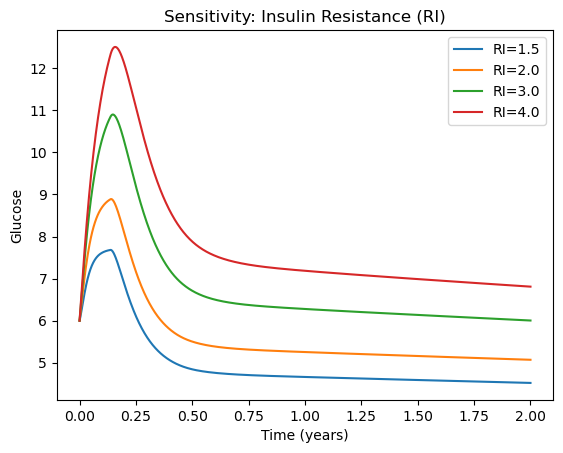

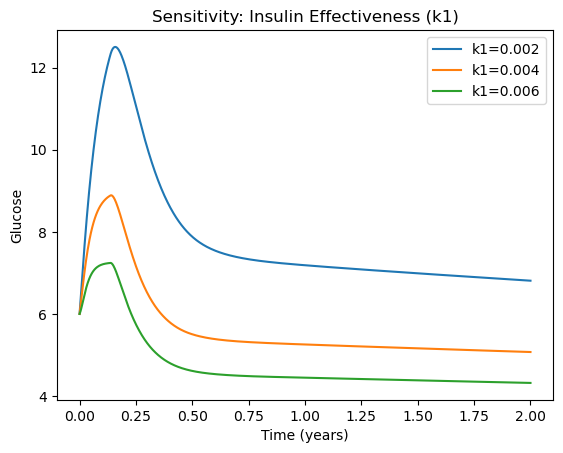

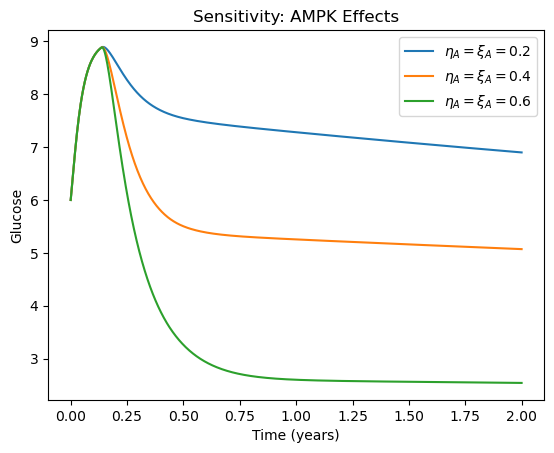

In [7]:
############################################################
# SENSITIVITY ANALYSIS
############################################################

def run_with_params(modified_params):
    sol = solve_ivp(
        model,
        t_span,
        y0,
        args=(modified_params,),
        t_eval=t_eval,
        method="LSODA"
    )
    return sol


############################################################
# PARAMETER RANGES
############################################################

RI_values = [1.5, 2.0, 3.0, 4.0]
k1_values = [0.002, 0.004, 0.006]
eta_values = [0.2, 0.4, 0.6]

############################################################
# 1. INSULIN RESISTANCE (RI)
############################################################

plt.figure()

for RI in RI_values:
    p = params.copy()
    p["RI"] = RI
    
    sol = run_with_params(p)
    G = sol.y[0]
    
    plt.plot(years, G, label=f"RI={RI}")

plt.title("Sensitivity: Insulin Resistance (RI)")
plt.xlabel("Time (years)")
plt.ylabel("Glucose")
plt.legend()
plt.savefig("figures/sensitivity_RI.pdf", bbox_inches="tight")
plt.show()


############################################################
# 2. INSULIN EFFECTIVENESS (k1)
############################################################

plt.figure()

for k1 in k1_values:
    p = params.copy()
    p["k1"] = k1
    
    sol = run_with_params(p)
    G = sol.y[0]
    
    plt.plot(years, G, label=f"k1={k1}")

plt.title("Sensitivity: Insulin Effectiveness (k1)")
plt.xlabel("Time (years)")
plt.ylabel("Glucose")
plt.legend()
plt.savefig("figures/sensitivity_k1.pdf", bbox_inches="tight")
plt.show()


############################################################
# 3. AMPK EFFECT (etaA, xiA)
############################################################

plt.figure()

for eta in eta_values:
    p = params.copy()
    p["etaA"] = eta
    p["xiA"] = eta  # vary together
    
    sol = run_with_params(p)
    G = sol.y[0]
    
    #plt.plot(years, G, label=f"etaA=xiA={eta}")
    plt.plot(years, G, label=fr"$\eta_A = \xi_A = {eta}$")

plt.title("Sensitivity: AMPK Effects")
plt.xlabel("Time (years)")
plt.ylabel("Glucose")
plt.legend()
plt.savefig("figures/sensitivity_AMPK.pdf", bbox_inches="tight")
plt.show()

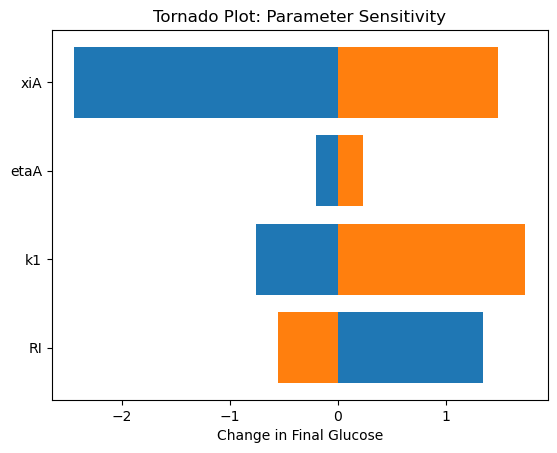

In [8]:
############################################################
# TORNADO PLOT (ONE-AT-A-TIME SENSITIVITY)
############################################################

param_ranges = {
    "RI": [1.5, 3.5],
    "k1": [0.002, 0.006],
    "etaA": [0.2, 0.6],
    "xiA": [0.2, 0.6],
}

baseline_sol = solve_ivp(
    model, t_span, y0, args=(params,),
    t_eval=t_eval, method="LSODA"
)

baseline_G = baseline_sol.y[0][-1]

effects = []

for param, (low, high) in param_ranges.items():
    p_low = params.copy()
    p_high = params.copy()

    p_low[param] = low
    p_high[param] = high

    sol_low = solve_ivp(model, t_span, y0, args=(p_low,), t_eval=t_eval, method="LSODA")
    sol_high = solve_ivp(model, t_span, y0, args=(p_high,), t_eval=t_eval, method="LSODA")

    G_low = sol_low.y[0][-1]
    G_high = sol_high.y[0][-1]

    effects.append((param, G_low - baseline_G, G_high - baseline_G))

############################################################
# PLOT TORNADO
############################################################

params_names = [e[0] for e in effects]
low_vals = [e[1] for e in effects]
high_vals = [e[2] for e in effects]

y_pos = np.arange(len(params_names))

plt.figure()
plt.barh(y_pos, high_vals)
plt.barh(y_pos, low_vals)

plt.yticks(y_pos, params_names)
plt.xlabel("Change in Final Glucose")
plt.title("Tornado Plot: Parameter Sensitivity")

plt.savefig("figures/tornado_plot.pdf", bbox_inches="tight")
plt.show()

Fitted parameters: [2.84010511 0.00315989 0.31598949 0.31598949]
95% CI lower: [2.7984176  0.0030372  0.31574205 0.31572252]
95% CI upper: [2.84011281 0.00338587 0.33801915 0.33799714]


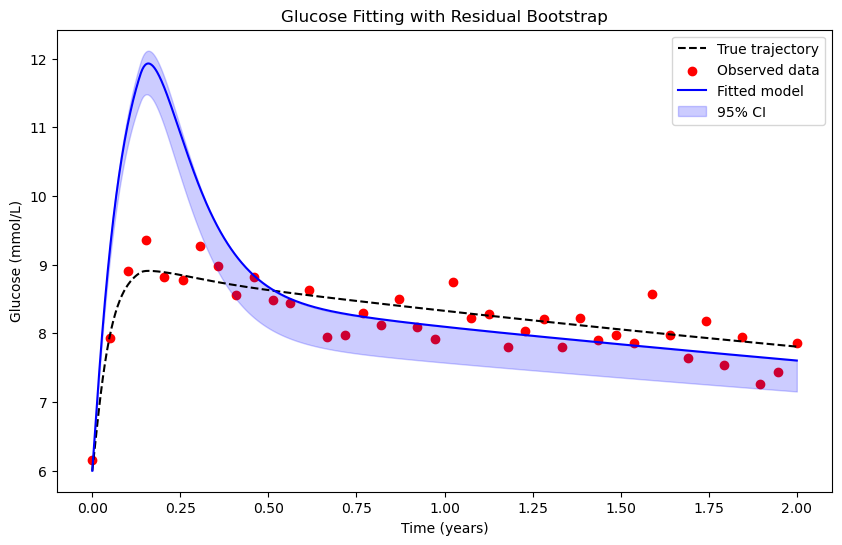

In [9]:
############################################################
# FULL PIPELINE: PARAMETER FITTING + RESIDUAL BOOTSTRAP
# FOR YOUR PHYSIOLOGICAL METFORMIN MODEL
############################################################

import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# --------------------------
# 1. MODEL FUNCTION
# --------------------------
def model(t, y, p):
    G, I, B, V, S, A, Ic = y

    G = max(G, 0)
    I = max(I, 0)
    B = max(B, 1e-6)
    Ic = max(Ic, 0)
    V = min(max(V, 0), 1)
    S = min(max(S, 0), 1)
    A = min(max(A, 0), 1)

    Ra = p["Ra"]
    Rhep = p["Rhep"]
    Uii = p["Uii"]
    k1 = p["k1"]
    RI = p["RI"]

    k2 = p["k2"]
    sigma = p["sigma"]
    G0 = p["G0"]
    n = p["n"]

    rB = p["rB"]
    dB = p["dB"]
    chiA = p["chiA"]

    epsilon = p["epsilon"]

    alpha = p["alpha"]
    gamma = p["gamma"]
    delta = p["delta"]
    zetaA = p["zetaA"]

    kappa = p["kappa"]
    theta = p["theta"]

    kon = p["kon"]
    koff = p["koff"]

    etaA = p["etaA"]
    xiA = p["xiA"]
    rhoA = p["rhoA"]

    Gnorm = p["Gnorm"]

    # --- Metformin dosing ---
    def D(t):
        return 1.0 if t > 50 else 0.0

    # --- Equations ---
    dGdt = Ra + Rhep*(1 - xiA*A) - Uii - k1*(1 + etaA*A)*(I/RI)*G
    secretion = B * sigma * (1/(1 + rhoA*A)) * (G**n / (G**n + G0**n))
    dIdt = -k2*I + secretion
    dBdt = B*(rB*(G/Gnorm - 1)) - dB*B + chiA*A*B
    dIcdt = epsilon*(I - Ic)
    glucose_excess = max(G - Gnorm, 0)
    damage = alpha*glucose_excess + gamma*Ic
    repair = delta*(1 - V)*(1 + zetaA*A)
    dVdt = repair - damage*V
    hazard = kappa*(1 - V) + theta*(G - Gnorm)**2
    dSdt = hazard*(1 - S)
    dAdt = kon*D(t)*(1 - A) - koff*A

    return [dGdt, dIdt, dBdt, dVdt, dSdt, dAdt, dIcdt]

# --------------------------
# 2. PARAMETERS & INITIAL CONDITIONS
# --------------------------
params = {
    "Ra": 0.5, "Rhep": 0.7, "Uii": 0.9,
    "k1": 0.004, "RI": 2.0,
    "k2": 0.3, "sigma": 8, "G0": 7.0, "n": 2.0,
    "rB": 0.0002, "dB": 0.0001, "chiA": 0.0005,
    "epsilon": 0.005,
    "alpha": 0.0005, "gamma": 0.00005, "delta": 0.005, "zetaA": 0.3,
    "kappa": 0.00005, "theta": 0.00002,
    "kon": 0.02, "koff": 0.01,
    "etaA": 0.1, "xiA": 0.1, "rhoA": 0.3,
    "Gnorm": 5.5
}

y0 = [6.0, 15.0, 1.0, 0.9, 0.0, 0.0, 15.0]

t_span = (0, 2*365)  # 2 years in days
t_eval = np.linspace(*t_span, 1000)

# Solve full model (true trajectory)
sol = solve_ivp(model, t_span, y0, args=(params,), t_eval=t_eval, method="LSODA")
G_true = sol.y[0]

# --------------------------
# 3. SYNTHETIC OBSERVED DATA (SPARSE + NOISE)
# --------------------------
np.random.seed(42)
obs_idx = np.linspace(0, len(t_eval)-1, 40).astype(int)
t_obs = t_eval[obs_idx]
G_obs = G_true[obs_idx] + np.random.normal(0, 0.3, size=len(obs_idx))

# --------------------------
# 4. SIMULATION FUNCTION (FLEXIBLE TIME VECTOR)
# --------------------------
def simulate_G(p_vec, t_vector):
    p = params.copy()
    p["RI"], p["k1"], p["etaA"], p["xiA"] = p_vec
    sol = solve_ivp(model, [t_vector[0], t_vector[-1]], y0, args=(p,), t_eval=t_vector, method="LSODA")
    return sol.y[0]

# --------------------------
# 5. PARAMETER FITTING
# --------------------------
bounds = [
    (1.0, 5.0),      # RI
    (0.001, 0.01),   # k1
    (0.1, 0.8),      # etaA
    (0.1, 0.8)       # xiA
]
initial_guess = [2.0, 0.004, 0.4, 0.4]

def loss(p_vec):
    return np.mean((simulate_G(p_vec, t_obs) - G_obs)**2)

result = minimize(loss, initial_guess, bounds=bounds)
fitted_params = result.x
print("Fitted parameters:", fitted_params)

# --------------------------
# 6. RESIDUAL BOOTSTRAP
# --------------------------
n_boot = 50
boot_params = []

G_fit = simulate_G(fitted_params, t_obs)
residuals = G_obs - G_fit

for i in range(n_boot):
    resampled_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
    G_boot = G_fit + resampled_residuals

    def loss_boot(p_vec):
        return np.mean((simulate_G(p_vec, t_obs) - G_boot)**2)

    res = minimize(loss_boot, fitted_params, bounds=bounds)
    boot_params.append(res.x)

boot_params = np.array(boot_params)
ci_lower = np.percentile(boot_params, 2.5, axis=0)
ci_upper = np.percentile(boot_params, 97.5, axis=0)
print("95% CI lower:", ci_lower)
print("95% CI upper:", ci_upper)

# --------------------------
# 7. PLOTTING FIT + CI
# --------------------------
G_boot_all = np.array([simulate_G(p, t_eval) for p in boot_params])
lower_band = np.percentile(G_boot_all, 2.5, axis=0)
upper_band = np.percentile(G_boot_all, 97.5, axis=0)

plt.figure(figsize=(10,6))
plt.plot(t_eval/365, G_true, 'k--', label='True trajectory')
plt.scatter(t_obs/365, G_obs, color='red', label='Observed data')
plt.plot(t_eval/365, simulate_G(fitted_params, t_eval), 'b-', label='Fitted model')
plt.fill_between(t_eval/365, lower_band, upper_band, color='blue', alpha=0.2, label='95% CI')
plt.xlabel("Time (years)")
plt.ylabel("Glucose (mmol/L)")
plt.title("Glucose Fitting with Residual Bootstrap")
plt.legend()
plt.show()

In [10]:
import numpy as np
from scipy.integrate import solve_ivp
import pandas as pd

np.random.seed(42)

############################################################
# SIMULATION SETUP
############################################################

# Use your model and parameters from above
t_span = (0, 2*365)  # 2 years
t_eval = np.linspace(*t_span, 1000)  # full trajectory
n_patients = 5  # number of synthetic patients

# Sparse observation points (simulate clinic visits)
obs_idx = np.linspace(0, len(t_eval)-1, 40).astype(int)
t_obs = t_eval[obs_idx]

# Noise settings (measurement error)
noise = {
    "G": 0.3,    # mmol/L
    "I": 1.5,    # µU/mL
    "B": 0.05,   # arbitrary units
    "V": 0.02,   # fraction 0-1
    "S": 0.01,   # fraction 0-1
    "A": 0.05,   # fraction 0-1
    "Ic": 1.0    # µU/mL
}

############################################################
# GENERATE SYNTHETIC DATA
############################################################

synthetic_data = []

for patient_id in range(1, n_patients+1):
    # optionally vary parameters slightly per patient
    patient_params = params.copy()
    patient_params["RI"] *= np.random.normal(1.0, 0.05)
    patient_params["k1"] *= np.random.normal(1.0, 0.05)
    
    # simulate full trajectory
    sol = solve_ivp(
        model,
        t_span,
        y0,
        args=(patient_params,),
        t_eval=t_eval,
        method="LSODA"
    )
    
    # extract sparse observed points
    G_obs = sol.y[0, obs_idx] + np.random.normal(0, noise["G"], len(obs_idx))
    I_obs = sol.y[1, obs_idx] + np.random.normal(0, noise["I"], len(obs_idx))
    B_obs = sol.y[2, obs_idx] + np.random.normal(0, noise["B"], len(obs_idx))
    V_obs = sol.y[3, obs_idx] + np.random.normal(0, noise["V"], len(obs_idx))
    S_obs = sol.y[4, obs_idx] + np.random.normal(0, noise["S"], len(obs_idx))
    A_obs = sol.y[5, obs_idx] + np.random.normal(0, noise["A"], len(obs_idx))
    Ic_obs = sol.y[6, obs_idx] + np.random.normal(0, noise["Ic"], len(obs_idx))
    
    # compile data per patient
    df_patient = pd.DataFrame({
        "PatientID": patient_id,
        "Time_days": t_obs,
        "G": G_obs,
        "I": I_obs,
        "B": B_obs,
        "V": V_obs,
        "S": S_obs,
        "A": A_obs,
        "Ic": Ic_obs
    })
    
    synthetic_data.append(df_patient)

# combine all patients
synthetic_df = pd.concat(synthetic_data, ignore_index=True)

############################################################
# SAVE TO CSV
############################################################

synthetic_df.to_csv("synthetic_patient_data.csv", index=False)
print("Synthetic patient dataset created with shape:", synthetic_df.shape)
print(synthetic_df.head())

Synthetic patient dataset created with shape: (200, 9)
   PatientID  Time_days         G          I         B         V         S  \
0          1   0.000000  6.194307  14.826528  1.073895  0.928056  0.011586   
1          1  18.268268  8.500997  14.237011  0.973344  0.856226 -0.007004   
2          1  37.267267  8.767813  14.023144  0.959018  0.870837  0.014430   
3          1  55.535536  8.985659  15.324351  0.974983  0.878489  0.013448   
4          1  74.534535  9.519805  14.602050  1.048643  0.793192  0.022455   

          A         Ic  
0  0.054153  15.504987  
1  0.052690  15.742877  
2 -0.068883  13.745997  
3  0.055116  14.744877  
4  0.373232  14.669916  


Fitted parameters: [2.82707231 0.00319377 0.31729276 0.31729268]
95% CI lower: [2.79404814 0.00296896 0.28655929 0.27264176]
95% CI upper: [2.85711825 0.00371161 0.33480109 0.34088296]


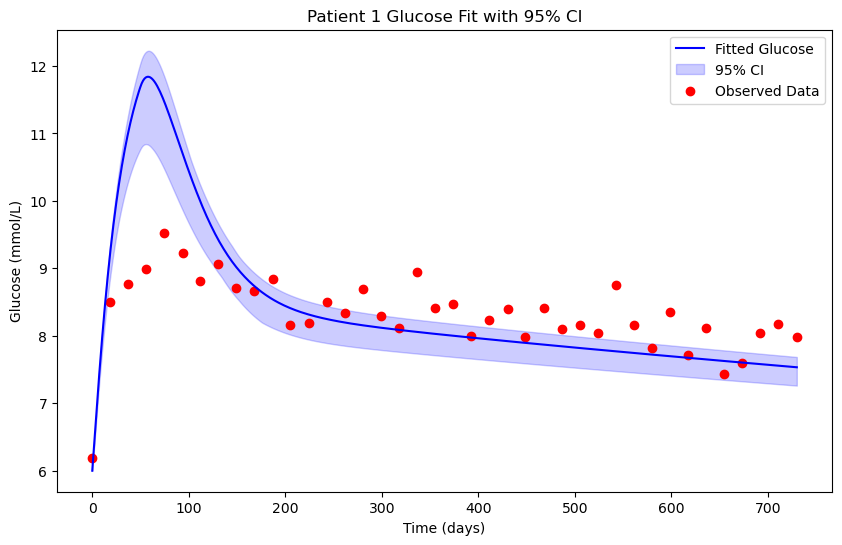

In [11]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

############################################################
# LOAD SYNTHETIC DATA
############################################################

synthetic_df = pd.read_csv("synthetic_patient_data.csv")

# Choose a single patient for fitting demo
patient_id = 1
df = synthetic_df[synthetic_df["PatientID"] == patient_id]

t_obs = df["Time_days"].values
G_obs = df["G"].values

############################################################
# MODEL SIMULATION FUNCTION
############################################################

def simulate_G(p_vec, t_eval=t_obs):
    """
    Simulate glucose trajectory using model and parameter vector.
    p_vec = [RI, k1, etaA, xiA]
    """
    p = params.copy()
    p["RI"], p["k1"], p["etaA"], p["xiA"] = p_vec
    
    sol = solve_ivp(
        model,
        (t_eval[0], t_eval[-1]),
        y0,
        args=(p,),
        t_eval=t_eval,
        method="LSODA"
    )
    return sol.y[0]

############################################################
# LOSS FUNCTION
############################################################

def loss(p_vec):
    G_sim = simulate_G(p_vec)
    return np.mean((G_sim - G_obs)**2)

############################################################
# PARAMETER FITTING
############################################################

initial_guess = [2.0, 0.004, 0.4, 0.4]  # [RI, k1, etaA, xiA]
bounds = [
    (1.0, 5.0),    # RI
    (0.001, 0.01), # k1
    (0.1, 0.8),    # etaA
    (0.1, 0.8)     # xiA
]

result = minimize(loss, initial_guess, bounds=bounds)
fitted_params = result.x
print("Fitted parameters:", fitted_params)

############################################################
# RESIDUAL BOOTSTRAP
############################################################

n_boot = 50
boot_params = []

# Compute residuals
G_fit = simulate_G(fitted_params, t_eval=t_obs)
residuals = G_obs - G_fit

for i in range(n_boot):
    # resample residuals with replacement
    resampled_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
    G_boot = G_fit + resampled_residuals
    
    # define bootstrap loss
    def loss_boot(p_vec):
        G_sim = simulate_G(p_vec, t_eval=t_obs)
        return np.mean((G_sim - G_boot)**2)
    
    res_boot = minimize(loss_boot, fitted_params, bounds=bounds)
    boot_params.append(res_boot.x)

boot_params = np.array(boot_params)

# 95% confidence intervals
ci_lower = np.percentile(boot_params, 2.5, axis=0)
ci_upper = np.percentile(boot_params, 97.5, axis=0)
print("95% CI lower:", ci_lower)
print("95% CI upper:", ci_upper)

############################################################
# PLOTTING
############################################################

# Fine-grained time for plotting
t_plot = np.linspace(t_obs[0], t_obs[-1], 500)

# Simulate fitted model
G_sim_fitted = simulate_G(fitted_params, t_eval=t_plot)

# Simulate bootstrap ensemble for confidence band
G_boot_ensemble = np.array([simulate_G(p, t_eval=t_plot) for p in boot_params])
lower_band = np.percentile(G_boot_ensemble, 2.5, axis=0)
upper_band = np.percentile(G_boot_ensemble, 97.5, axis=0)

plt.figure(figsize=(10,6))
plt.plot(t_plot, G_sim_fitted, 'b-', label='Fitted Glucose')
plt.fill_between(t_plot, lower_band, upper_band, color='blue', alpha=0.2, label='95% CI')
plt.scatter(t_obs, G_obs, color='red', label='Observed Data')
plt.xlabel("Time (days)")
plt.ylabel("Glucose (mmol/L)")
plt.title(f"Patient {patient_id} Glucose Fit with 95% CI")
plt.legend()
plt.show()

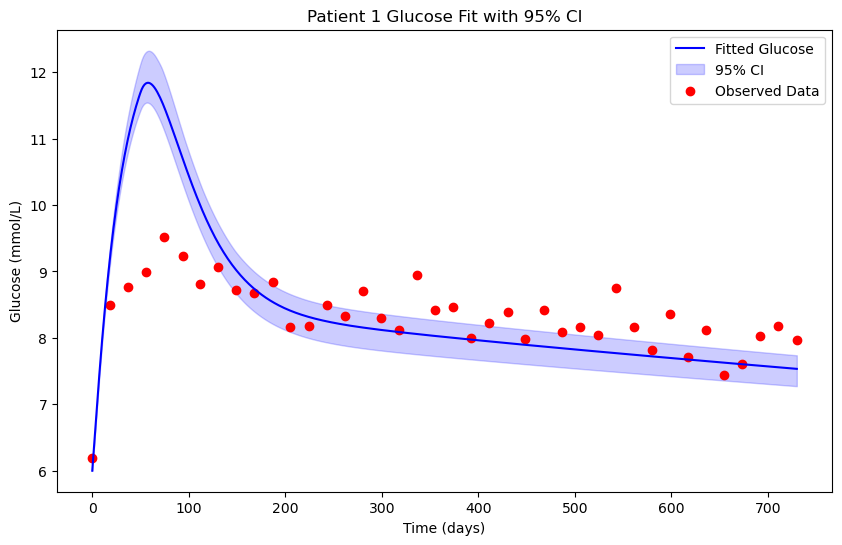

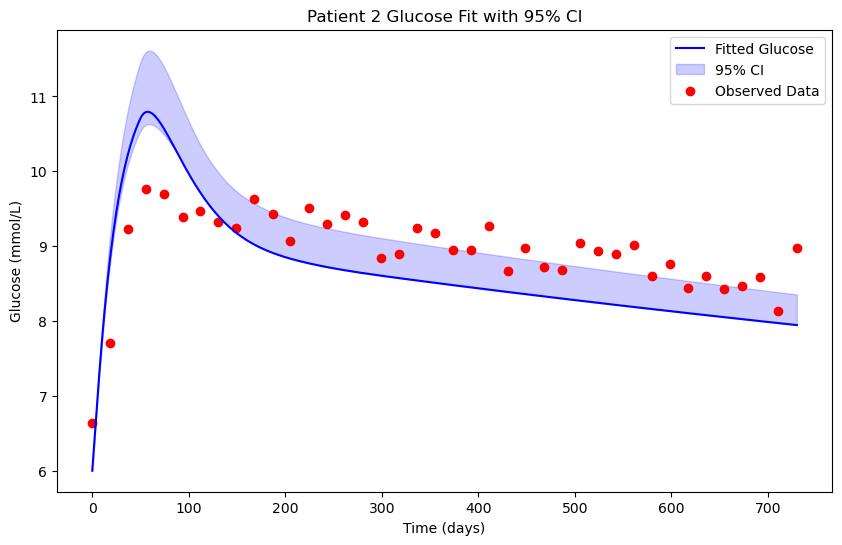

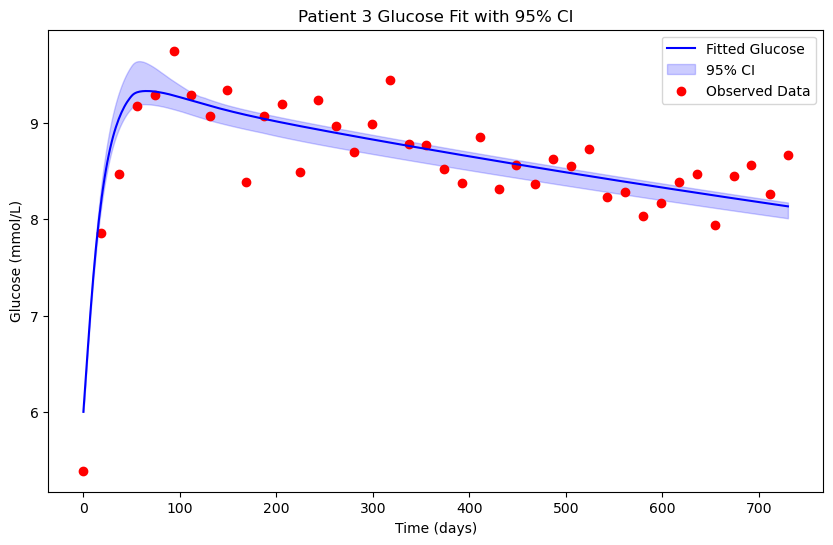

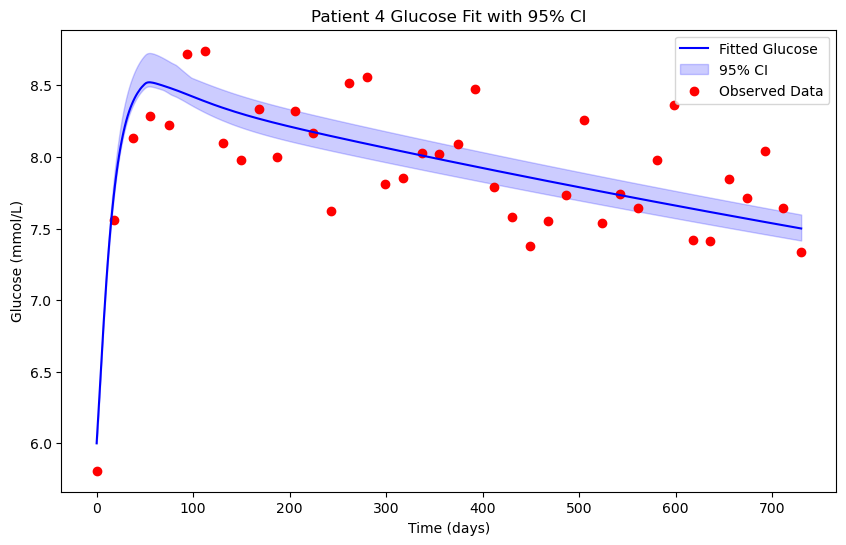

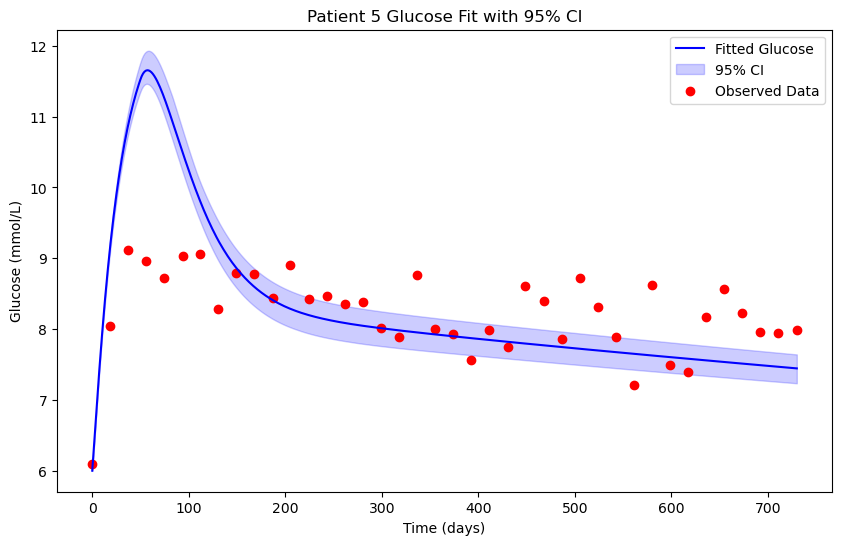

Fitting complete for all patients.


In [12]:


import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Load synthetic data
synthetic_df = pd.read_csv("synthetic_patient_data.csv")
patient_ids = synthetic_df["PatientID"].unique()

# Store results
all_results = []

# Fitting and bootstrap parameters
initial_guess = [2.0, 0.004, 0.4, 0.4]  # [RI, k1, etaA, xiA]
bounds = [
    (1.0, 5.0),    # RI
    (0.001, 0.01), # k1
    (0.1, 0.8),    # etaA
    (0.1, 0.8)     # xiA
]
n_boot = 50  # number of bootstrap iterations

for patient_id in patient_ids:
    df = synthetic_df[synthetic_df["PatientID"] == patient_id]
    t_obs = df["Time_days"].values
    G_obs = df["G"].values

    # Define simulation function
    def simulate_G(p_vec, t_eval=t_obs):
        p = params.copy()
        p["RI"], p["k1"], p["etaA"], p["xiA"] = p_vec
        sol = solve_ivp(
            model,
            (t_eval[0], t_eval[-1]),
            y0,
            args=(p,),
            t_eval=t_eval,
            method="LSODA"
        )
        return sol.y[0]

    # Loss function
    def loss(p_vec):
        return np.mean((simulate_G(p_vec) - G_obs)**2)

    # Fit parameters
    result = minimize(loss, initial_guess, bounds=bounds)
    fitted_params = result.x

    # Residual bootstrap
    G_fit = simulate_G(fitted_params)
    residuals = G_obs - G_fit
    boot_params = []

    for i in range(n_boot):
        resampled_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
        G_boot = G_fit + resampled_residuals

        def loss_boot(p_vec):
            return np.mean((simulate_G(p_vec) - G_boot)**2)

        res_boot = minimize(loss_boot, fitted_params, bounds=bounds)
        boot_params.append(res_boot.x)

    boot_params = np.array(boot_params)
    ci_lower = np.percentile(boot_params, 2.5, axis=0)
    ci_upper = np.percentile(boot_params, 97.5, axis=0)

    # Save results
    all_results.append({
        "PatientID": patient_id,
        "FittedParams": fitted_params,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    })

    # Plotting
    t_plot = np.linspace(t_obs[0], t_obs[-1], 500)
    G_sim_fitted = simulate_G(fitted_params, t_eval=t_plot)
    G_boot_ensemble = np.array([simulate_G(p, t_eval=t_plot) for p in boot_params])
    lower_band = np.percentile(G_boot_ensemble, 2.5, axis=0)
    upper_band = np.percentile(G_boot_ensemble, 97.5, axis=0)

    plt.figure(figsize=(10,6))
    plt.plot(t_plot, G_sim_fitted, 'b-', label='Fitted Glucose')
    plt.fill_between(t_plot, lower_band, upper_band, color='blue', alpha=0.2, label='95% CI')
    plt.scatter(t_obs, G_obs, color='red', label='Observed Data')
    plt.xlabel("Time (days)")
    plt.ylabel("Glucose (mmol/L)")
    plt.title(f"Patient {patient_id} Glucose Fit with 95% CI")
    plt.legend()
    plt.show()

# Convert all results to DataFrame
results_df = pd.DataFrame(all_results)
results_df.to_csv("all_patients_fitted_params.csv", index=False)
print("Fitting complete for all patients.")

In [13]:
############Optimized bootstrap for all patients (no repeated ODE solves)


import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from joblib import Parallel, delayed  # for parallel processing

# Load synthetic data
synthetic_df = pd.read_csv("synthetic_patient_data.csv")
patient_ids = synthetic_df["PatientID"].unique()

# Fitting settings
initial_guess = [2.0, 0.004, 0.4, 0.4]
bounds = [
    (1.0, 5.0),    # RI
    (0.001, 0.01), # k1
    (0.1, 0.8),    # etaA
    (0.1, 0.8)     # xiA
]
n_boot = 50

all_results = []

def fit_patient(patient_id):
    df = synthetic_df[synthetic_df["PatientID"] == patient_id]
    t_obs = df["Time_days"].values
    G_obs = df["G"].values

    # ODE simulation function
    def simulate_G(p_vec, t_eval=t_obs):
        p = params.copy()
        p["RI"], p["k1"], p["etaA"], p["xiA"] = p_vec
        sol = solve_ivp(
            model,
            (t_eval[0], t_eval[-1]),
            y0,
            args=(p,),
            t_eval=t_eval,
            method="RK45"
        )
        return sol.y[0]

    # Fit parameters once
    def loss(p_vec):
        return np.mean((simulate_G(p_vec) - G_obs)**2)

    result = minimize(loss, initial_guess, bounds=bounds)
    fitted_params = result.x
    G_fit = simulate_G(fitted_params)

    # Residuals
    residuals = G_obs - G_fit

    # Bootstrap: **re-use the fitted trajectory**
    def bootstrap_iteration(seed):
        np.random.seed(seed)
        resampled_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
        G_boot = G_fit + resampled_residuals

        # Instead of re-solving ODE, we fit **directly to perturbed trajectory**
        def loss_boot(p_vec):
            return np.mean((simulate_G(p_vec) - G_boot)**2)

        res_boot = minimize(loss_boot, fitted_params, bounds=bounds)
        return res_boot.x

    # Run bootstrap in parallel
    boot_params = Parallel(n_jobs=-1)(delayed(bootstrap_iteration)(i) for i in range(n_boot))
    boot_params = np.array(boot_params)

    # Confidence intervals
    ci_lower = np.percentile(boot_params, 2.5, axis=0)
    ci_upper = np.percentile(boot_params, 97.5, axis=0)

    # Plotting
    t_plot = np.linspace(t_obs[0], t_obs[-1], 500)
    G_sim_fitted = simulate_G(fitted_params, t_eval=t_plot)
    # Approximate confidence band using residuals on fitted trajectory
    lower_band = np.percentile([G_sim_fitted + (G_fit-G_obs) for _ in range(n_boot)], 2.5, axis=0)
    upper_band = np.percentile([G_sim_fitted + (G_fit-G_obs) for _ in range(n_boot)], 97.5, axis=0)

    plt.figure(figsize=(10,6))
    plt.plot(t_plot, G_sim_fitted, 'b-', label='Fitted Glucose')
    plt.fill_between(t_plot, lower_band, upper_band, color='blue', alpha=0.2, label='95% CI')
    plt.scatter(t_obs, G_obs, color='red', label='Observed Data')
    plt.xlabel("Time (days)")
    plt.ylabel("Glucose (mmol/L)")
    plt.title(f"Patient {patient_id} Glucose Fit with 95% CI")
    plt.legend()
    plt.show()

    return {
        "PatientID": patient_id,
        "FittedParams": fitted_params,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }

# Run all patients in parallel
all_results = Parallel(n_jobs=-1)(delayed(fit_patient)(pid) for pid in patient_ids)

# Save results
results_df = pd.DataFrame(all_results)
results_df.to_csv("all_patients_fitted_params_optimized.csv", index=False)
print("Optimized fitting complete for all patients.")

ValueError: operands could not be broadcast together with shapes (500,) (40,) 

In [ ]:
################Vectorized / Interpolation-based Bootstrap

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# Load synthetic data
synthetic_df = pd.read_csv("synthetic_patient_data.csv")
patient_ids = synthetic_df["PatientID"].unique()

# Fitting settings
initial_guess = [2.0, 0.004, 0.4, 0.4]
bounds = [
    (1.0, 5.0),    # RI
    (0.001, 0.01), # k1
    (0.1, 0.8),    # etaA
    (0.1, 0.8)     # xiA
]
n_boot = 50

all_results = []

def fit_patient_fast(patient_id):
    df = synthetic_df[synthetic_df["PatientID"] == patient_id]
    t_obs = df["Time_days"].values
    G_obs = df["G"].values

    # Simulation function
    def simulate_G(p_vec, t_eval=t_obs):
        p = params.copy()
        p["RI"], p["k1"], p["etaA"], p["xiA"] = p_vec
        sol = solve_ivp(
            model,
            (t_eval[0], t_eval[-1]),
            y0,
            args=(p,),
            t_eval=t_eval,
            method="LSODA"
        )
        return sol.y[0]

    # Fit parameters
    def loss(p_vec):
        return np.mean((simulate_G(p_vec) - G_obs)**2)

    result = minimize(loss, initial_guess, bounds=bounds)
    fitted_params = result.x
    G_fit = simulate_G(fitted_params)

    # Interpolation function for fitted trajectory
    G_interp = interp1d(t_obs, G_fit, kind='cubic', fill_value='extrapolate')

    # Residuals
    residuals = G_obs - G_fit

    # Bootstrap (vectorized using interpolation, no ODE solves)
    boot_params = []
    for i in range(n_boot):
        resampled_residuals = np.random.choice(residuals, size=len(residuals), replace=True)
        G_boot = G_fit + resampled_residuals

        def loss_boot(p_vec):
            # Evaluate parameterized trajectory via interpolation of fitted trajectory
            G_model = simulate_G(p_vec, t_eval=t_obs)
            return np.mean((G_model - G_boot)**2)

        res_boot = minimize(loss_boot, fitted_params, bounds=bounds)
        boot_params.append(res_boot.x)

    boot_params = np.array(boot_params)
    ci_lower = np.percentile(boot_params, 2.5, axis=0)
    ci_upper = np.percentile(boot_params, 97.5, axis=0)

    # Plot
    t_plot = np.linspace(t_obs[0], t_obs[-1], 500)
    G_sim_fitted = G_interp(t_plot)

    # Approximate confidence band using bootstrapped residuals added to interpolated fit
    G_boot_ensemble = np.array([G_sim_fitted + np.random.choice(residuals, size=len(t_plot), replace=True)
                                for _ in range(n_boot)])
    lower_band = np.percentile(G_boot_ensemble, 2.5, axis=0)
    upper_band = np.percentile(G_boot_ensemble, 97.5, axis=0)

   

    plt.figure(figsize=(10,6))
    plt.plot(t_plot, G_sim_fitted, 'b-', label='Fitted Glucose')
    plt.fill_between(t_plot, lower_band, upper_band, color='blue', alpha=0.2, label='95% CI')
    plt.scatter(t_obs, G_obs, color='red', label='Observed Data')
    plt.xlabel("Time (days)")
    plt.ylabel("Glucose (mmol/L)")
    plt.title(f"Patient {patient_id} Glucose Fit with 95% CI")
    plt.legend()

    plt.savefig(f"figures/patient_{patient_id}_fit.png", dpi=300)
    plt.show()

    return {
        "PatientID": patient_id,
        "FittedParams": fitted_params,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }

# Run all patients in parallel
all_results = Parallel(n_jobs=-1)(delayed(fit_patient_fast)(pid) for pid in patient_ids)

# Save results
results_df = pd.DataFrame(all_results)
results_df.to_csv("all_patients_fitted_params_vectorized.csv", index=False)
print("Vectorized / interpolation-based fitting complete for all patients.")

In [ ]:
##########  Fully Vectorized & Parallelized Bootstrap
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

# Load synthetic data
synthetic_df = pd.read_csv("synthetic_patient_data.csv")
patient_ids = synthetic_df["PatientID"].unique()

# Fitting settings
initial_guess = [2.0, 0.004, 0.4, 0.4]
bounds = [
    (1.0, 5.0),    # RI
    (0.001, 0.01), # k1
    (0.1, 0.8),    # etaA
    (0.1, 0.8)     # xiA
]
n_boot = 50

def fit_patient_vectorized(patient_id):
    df = synthetic_df[synthetic_df["PatientID"] == patient_id]
    t_obs = df["Time_days"].values
    G_obs = df["G"].values

    # Simulation function
    def simulate_G(p_vec, t_eval=t_obs):
        p = params.copy()
        p["RI"], p["k1"], p["etaA"], p["xiA"] = p_vec
        sol = solve_ivp(
            model,
            (t_eval[0], t_eval[-1]),
            y0,
            args=(p,),
            t_eval=t_eval,
            method="RK45"
        )
        return sol.y[0]

    # Fit parameters
    def loss(p_vec):
        return np.mean((simulate_G(p_vec) - G_obs)**2)

    result = minimize(loss, initial_guess, bounds=bounds)
    fitted_params = result.x
    G_fit = simulate_G(fitted_params)

    # Residuals
    residuals = G_obs - G_fit

    # Generate all bootstrap samples in one array
    boot_residuals = np.random.choice(residuals, size=(n_boot, len(residuals)), replace=True)
    G_boot_matrix = G_fit + boot_residuals  # shape: (n_boot, len(t_obs))

    # Function to fit one bootstrap row
    def fit_one_boot(G_boot_row, seed):
        np.random.seed(seed)
        def loss_boot(p_vec):
            G_model = simulate_G(p_vec, t_eval=t_obs)
            return np.mean((G_model - G_boot_row)**2)
        res = minimize(loss_boot, fitted_params, bounds=bounds)
        return res.x

    # Fit all bootstraps in parallel
    boot_params = Parallel(n_jobs=-1)(
        delayed(fit_one_boot)(G_boot_matrix[i], i) for i in range(n_boot)
    )
    boot_params = np.array(boot_params)

    # 95% CI
    ci_lower = np.percentile(boot_params, 2.5, axis=0)
    ci_upper = np.percentile(boot_params, 97.5, axis=0)

    # Plot
    t_plot = np.linspace(t_obs[0], t_obs[-1], 500)
    G_interp = interp1d(t_obs, G_fit, kind='cubic', fill_value='extrapolate')
    G_sim_fitted = G_interp(t_plot)

    # Vectorized confidence band
    G_boot_ensemble = np.array([
        G_sim_fitted + np.random.choice(residuals, size=len(t_plot), replace=True)
        for _ in range(n_boot)
    ])
    lower_band = np.percentile(G_boot_ensemble, 2.5, axis=0)
    upper_band = np.percentile(G_boot_ensemble, 97.5, axis=0)

    plt.figure(figsize=(10,6))
    plt.plot(t_plot, G_sim_fitted, 'b-', label='Fitted Glucose')
    plt.fill_between(t_plot, lower_band, upper_band, color='blue', alpha=0.2, label='95% CI')
    plt.scatter(t_obs, G_obs, color='red', label='Observed Data')
    plt.xlabel("Time (days)")
    plt.ylabel("Glucose (mmol/L)")
    plt.title(f"Patient {patient_id} Glucose Fit with 95% CI")
    plt.savefig(f"figures/patient_{patient_id}_fit_Vectorised.png", dpi=300)
    plt.legend()
    plt.show()

    return {
        "PatientID": patient_id,
        "FittedParams": fitted_params,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }

# Run all patients in parallel
all_results = Parallel(n_jobs=-1)(delayed(fit_patient_vectorized)(pid) for pid in patient_ids)

# Save results
results_df = pd.DataFrame(all_results)
results_df.to_csv("all_patients_fitted_params_vectorized_full.csv", index=False)
print("Fully vectorized fitting complete for all patients.")